# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos: Javier García Masegosa y Ander Amatriain Amiano  <br>
Url: https://github.com/.../03MAIR---Algoritmos-de-Optimizacion---2019/tree/master/SEMINARIO<br>
Problema: Organizar los horarios de partidos de La Liga

Descripción del problema:

Desde la La Liga de fútbol profesional se pretende organizar los horarios de los partidos de liga de cada jornada. Se conocen algunos datos que nos deben llevar a diseñar un algoritmo que realice la asignación de los partidos a los horarios de forma que maximice la audiencia.

(*) La respuesta es obligatoria





                                        

In [1]:
# Librerías que usamos
import math
import itertools
import random
import matplotlib.pyplot as plt

(*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>



¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.




Respuesta

Para calcular el espacio de soluciones sin restricciones, debemos tener en cuenta que disponemos de 10 partidos a programar y 10 horarios disponibles en total. Además, el enunciado especifica que "es posible la coincidencia de horarios", lo que significa que un mismo horario se pueden tener múltiples partidos al mismo tiempo. Al no tener restricciones, cada uno de los 10 partidos puede ser asignado a cualquiera de los 10 horarios de forma independiente. Matemáticamente, esto se modela como Variaciones con repetición de 10 elementos tomados de 10 en 10. $$VR_{10,10} = 10^{10}$$Por lo tanto, sin tener en cuenta ninguna restricción, el número total de combinaciones posibles es de 10.000.000.000 (10 mil millones) de posibilidades.



Respecto a la segunda pregunta, el enunciado especifica que debemos asignar obligatoriamente siempre un partido el viernes y un partido el lunes. Para maximizar la audiencia, interpretaremos esto como exactamente un partido el viernes a las 20h y exactamente un partido el lunes a las 20h. Está permitido el solapamiento ya que es posible la coincidencia de horarios. Esto significa que, para el resto de los partidos del fin de semana, no hay límite en cuántos partidos pueden jugarse a la misma hora.

Teniendo en cuenta las reglas anteriores, tenemos:

- Asignar el partido del Viernes. De los 10 partidos totales de la jornada, debemos elegir 1 para el viernes. Combinatoriamente, son combinaciones de 10 elementos tomados de 1 en 1: $\binom{10}{1} = 10$ posibilidades.

- Asignar el partido del Lunes. De los 9 partidos que nos quedan sin asignar, elegimos 1 para el lunes. $\binom{9}{1} = 9$ posibilidades.

- Asignar los partidos del Fin de Semana. Nos quedan 8 partidos libres y 8 horarios disponibles (los 4 del sábado y los 4 del domingo). Como se permiten coincidencias, cada uno de los 8 partidos puede ubicarse en cualquiera de los 8 horarios de forma independiente. Esto se modela con variaciones con repetición:
$VR_{8,8} = 8^8 = 16.777.216$ posibilidades.

Por lo tanto, el espacio de soluciones final, aplicando el principio multiplicativo a los tres pasos anteriores, da un total de posibilidades:$$Total = 10 \times 9 \times 8^8$$ $$Total = 90 \times 16.777.216 = 1.509.949.440$$

Podemos ver que teniendo en cuenta todas las restricciones, el espacio de soluciones se reduce a 1.509.949.440 combinaciones posibles.

Modelo para el espacio de soluciones<br>
(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)


Respuesta

Para modelar este problema de forma eficiente, dividiremos las estructuras de datos en dos bloques, una para los datos de entrada y la otra para la codificación de la solución.

La estructura que mejor vemos para los pesos, coeficientes y categorías son los diccionarios, ya que los diccionarios permiten un acceso a los valores en tiempo constante $O(1)$ mediante claves (por ejemplo, buscar el coeficiente de penalización por coincidencia usando el número de coincidencias como clave, o el coeficiente del horario usando). Dado que la función objetivo se evaluará miles o millones de veces en una metaheurística, la velocidad de consulta tiene que ser lo que más nos interese. Para la lista de partidos a organizar, una Lista de diccionarios o una Lista de tuplas es lo que tiene más sentido, al menos de momento.

Para representar una solución concreta (la asignación de los 10 partidos a los horarios), la estructura óptima es un Array unidimensional de longitud 10 donde cada posicion sea un partido. El índice de la lista representará el identificador del partido (del 0 al 9), y el valor almacenado en esa posición será el identificador del horario asignado (del 0 al 9) como por ejemplo, solucion = [0, 5, 2, ...] significa que el Partido 0 se juega en el Horario 0 (Viernes 20h), el Partido 1 se juega en el Horario 5 (Sábado 20h), etc.

Esta estructura nos facilita mucho las cosas ya que cambiar el horario de un partido es simplemente modificar un valor en un índice solucion[i] = nuevo_horario, una operación $O(1)$. Además, evita crear estructuras matriciales dispersas que consumirían más memoria y tiempo de procesamiento.

Según el modelo para el espacio de soluciones<br>
(*)¿Cual es la función objetivo?


(*)¿Es un problema de maximización o minimización?

Respuesta

Es un problema de maximización. El objetivo principal que persigue La Liga es asignar los partidos a los distintos horarios disponibles de forma que se maximice la audiencia total de televisión generada en la jornada.

La función objetivo $f(x)$ se encarga de calcular la audiencia total estimada para una configuración específica de horarios, que es nuestra solución $x$. Para calcular la audiencia de un partido individual, la función debe multiplicar tres factores:

- Audiencia Base: Determinada por el cruce de las categorías de los dos equipos (A, B o C).
- Ponderación Horaria: Un coeficiente reductor que depende del día y la hora en la que se ubica el partido.
- Corrección por Coincidencia: Un factor de penalización que se aplica si hay varios partidos emitiéndose en la misma franja horaria.

Por lo tanto si tenemos un conjunto de 10 partidos ($P$), la función objetivo que queremos maximizar se define como la sumatoria de la audiencia de cada partido $i$:$$Fitness(x) = \sum_{i=1}^{10} (Base(i) \times Horario(x_i) \times Coincidencia(x_i))$$Donde $x_i$ representa el horario asignado al partido $i$ en la solución actual.

In [2]:
# Función Objetivo, le pasamos una solucion y nos devuelve la audiencia total estimada para esa solución
def calcular_audiencia(solucion, partidos, audiencia_base, coeficientes_horario, penalizacion_coincidencia):
    audiencia_total = 0.0
    
    # Primero necesitamos saber cuántos partidos van en cada horario para calcular penalizaciones
    # Inicializamos diccionario: clave=horario (0-9), valor=cantidad de partidos en ese horario
    conteo_horarios = {i: 0 for i in range(10)}
    
    # Recorremos la solución y contamos cuántos partidos se asignan a cada horario
    for horario in solucion:  # horario es un número del 0 al 9
        conteo_horarios[horario] += 1  # Incrementamos el contador para ese horario
        
    # Recorremos cada uno de los 10 partidos
    for i, partido in enumerate(partidos):  # i=índice del partido, partido=diccionario de ese partido
        
        # Extraemos las categorías del equipo 1 y equipo 2
        cat1, cat2 = partido['cat1'], partido['cat2']  # cat1, cat2 ∈ {'A', 'B', 'C'}
        
        # Buscamos la audiencia base en el diccionario
        # Si exista la tupla (cat1, cat2)
        if (cat1, cat2) in audiencia_base:
            base = audiencia_base[(cat1, cat2)]  # Obtenemos la audiencia base
        else:
            # Si no existe (porque está invertida como (cat2, cat1)), buscamos al revés
            # Esto es necesario porque a veces tenemos C-B en lugar de B-C
            base = audiencia_base[(cat2, cat1)]
        
        # Obtenemos el horario asignado a este partido en la solución actual
        horario_asignado = solucion[i]  # Número entre 0 y 9
        # Multiplicamos por el coeficiente de ese horario (el horario 4 y 8 tienen coef 1.0 - máximos)
        ponderacion = coeficientes_horario[horario_asignado]
        
        # Si N partidos se juegan al mismo tiempo, cada uno sufre una penalización
        # Contamos cuántos partidos más hay en ese horario (N-1, excluyendo el actual)
        num_coincidencias = conteo_horarios[horario_asignado] - 1
        # Buscamos el factor de penalización según el número de coincidencias
        penalizacion = penalizacion_coincidencia[num_coincidencias]
        
        # Multiplicamos los tres factores: base × ponderación × penalización
        audiencia_partido = base * ponderacion * penalizacion
        # Sumamos la audiencia de este partido al total de la jornada
        audiencia_total += audiencia_partido
        
    # Retornamos la audiencia total estimada para la solución completa
    return audiencia_total

Vamos ahora probar esta función con el ejemplo que hay en el pdf.

In [3]:

audiencia_base = {
    ('A', 'A'): 2.0,    # Partido entre dos equipos de máxima categoría (Madrid vs Barça)
    ('A', 'B'): 1.3,    # Partido entre un equipo élite y uno medio
    ('A', 'C'): 1.0,    # Partido entre un equipo élite y uno pequeño
    ('B', 'B'): 0.9,    # Partido entre dos equipos de media categoría
    ('B', 'C'): 0.75,   # Partido entre un equipo medio y uno pequeño
    ('C', 'C'): 0.47    # Partido entre dos equipos pequeños
}


coeficientes_horario = [
    0.4,   # Horario 0 (Viernes 20h) - audiciencia baja (muchos trabajando)
    0.55,  # Horario 1 (Sábado temprano)
    0.7,   # Horario 2 (Sábado mid-day)
    0.8,   # Horario 3 (Sábado tarde)
    1.0,   # Horario 4 (Sábado prime-time) - MEJOR HORARIO
    0.45,  # Horario 5 (Domingo temprano)
    0.75,  # Horario 6 (Domingo mid-day)
    0.85,  # Horario 7 (Domingo tarde)
    1.0,   # Horario 8 (Domingo prime-time) - MEJOR HORARIO
    0.4    # Horario 9 (Lunes 20h) - audiencia baja (mucho cansancio)
]


penalizacion_coincidencia = [
    1.0,   # 0 coincidencias (único partido en ese horario) - sin penalización
    0.75,  # 1 coincidencia (2 partidos al mismo tiempo)
    0.55,  # 2 coincidencias (3 partidos al mismo tiempo)
    0.40,  # 3 coincidencias (4 partidos al mismo tiempo)
    0.30,  # 4 coincidencias (5 partidos al mismo tiempo)
    0.25,  # 5 coincidencias (6 partidos al mismo tiempo)
    0.22,  # 6 coincidencias (7 partidos al mismo tiempo)
    0.20,  # 7 coincidencias (8 partidos al mismo tiempo)
    0.20,  # 8 coincidencias (9 partidos al mismo tiempo)
    0.20   # 9 coincidencias (10 partidos al mismo tiempo - caso extremo)
]

# Cada partido es un diccionario con: id, nombres de equipos, y categorías
partidos_ejemplo = [
    {'id': 0, 'eq1': 'Celta', 'cat1': 'B', 'eq2': 'Real Madrid', 'cat2': 'A'},
    {'id': 1, 'eq1': 'Valencia', 'cat1': 'B', 'eq2': 'R. Sociedad', 'cat2': 'A'},
    {'id': 2, 'eq1': 'Mallorca', 'cat1': 'C', 'eq2': 'Eibar', 'cat2': 'C'},
    {'id': 3, 'eq1': 'Athletic', 'cat1': 'B', 'eq2': 'Barcelona', 'cat2': 'A'},
    {'id': 4, 'eq1': 'Leganés', 'cat1': 'C', 'eq2': 'Osasuna', 'cat2': 'C'},
    {'id': 5, 'eq1': 'Villarreal', 'cat1': 'B', 'eq2': 'Granada', 'cat2': 'C'},
    {'id': 6, 'eq1': 'Alavés', 'cat1': 'B', 'eq2': 'Levante', 'cat2': 'B'},
    {'id': 7, 'eq1': 'Espanyol', 'cat1': 'B', 'eq2': 'Sevilla', 'cat2': 'B'},
    {'id': 8, 'eq1': 'Betis', 'cat1': 'B', 'eq2': 'Valladolid', 'cat2': 'C'},
    {'id': 9, 'eq1': 'Atlético', 'cat1': 'B', 'eq2': 'Getafe', 'cat2': 'B'}
]


# Cada índice = partido_id, cada valor = horario asignado (0-9)
solucion_ejemplo_pdf = [0, 1, 2, 3, 4, 6, 6, 7, 8, 9]
# Significado: Partido 0→Viernes (h0), Partido 1→Sábado h1, ..., Partido 6 y 7→ambos en Sábado h6 (coinciden)


# Ejecutamos calcular_audiencia con la solución del PDF para validar que implementamos correctamente
resultado = calcular_audiencia(solucion_ejemplo_pdf, partidos_ejemplo, audiencia_base, coeficientes_horario, penalizacion_coincidencia)

# Mostramos el resultado (audiencia total en millones de espectadores)
print(f"Audiencia Total Estimada: {round(resultado, 2)} Millones de espectadores")

Audiencia Total Estimada: 5.88 Millones de espectadores


Diseña un algoritmo para resolver el problema por fuerza bruta

Respuesta

In [4]:
# Algoritmo de Fuerza Bruta para encontrar la mejor asignación de horarios a partidos
def fuerza_bruta_audiencias(partidos, audiencia_base, coeficientes_horario, penalizacion_coincidencia, max_iteraciones=100000):
    # max_iteraciones: Límite de seguridad para no esperar eternamente
    
    mejor_solucion = None      # Mejor solución encontrada hasta ahora
    mejor_audiencia = -1       # Mejor audiencia encontrada hasta ahora
    iteraciones = 0            # Contador de soluciones evaluadas
    
    # Va del 0 al 9 (total de 10 partidos a asignar)
    indices_partidos = list(range(10))
    
    # Horarios 1-8 son para Sábado y Domingo (4 de cada)
    # El horario 0 es Viernes y el 9 es Lunes (fijos)
    horarios_finde = list(range(1, 9))  # [1, 2, 3, 4, 5, 6, 7, 8]
    
    # Primero elegimos qué partido va el Viernes y cuál el Lunes
    # itertools.permutations(indices_partidos, 2) genera todas las parejas ordenadas
    for partido_viernes, partido_lunes in itertools.permutations(indices_partidos, 2):
        # partido_viernes: ID del partido que se juega el viernes (horario 0)
        # partido_lunes: ID del partido que se juega el lunes (horario 9)
        
        # Estos 8 partidos se deben asignar a los 8 horarios del fin de semana (1-8)
        partidos_restantes = [p for p in indices_partidos if p != partido_viernes and p != partido_lunes]
        # partidos_restantes tendrá exactamente 8 partidos
        
        # itertools.product(horarios_finde, repeat=8) genera TODAS las combinaciones
        # con repetición de 8 elementos del conjunto {1,2,3,4,5,6,7,8}
        # Esto da 8^8 = 16,777,216 combinaciones (combinatoria con repetición)
        for asignacion_finde in itertools.product(horarios_finde, repeat=8):
            # asignacion_finde es una tupla de 8 elementos, cada uno ∈ {1,2,3,4,5,6,7,8}
            
            # Creamos lista de -1's, después la vamos llenando
            solucion_actual = [-1] * 10  # 10 posiciones, una por cada partido
            
            # Asignamos el partido del viernes (horario 0)
            solucion_actual[partido_viernes] = 0
            
            # Asignamos el partido del lunes (horario 9)
            solucion_actual[partido_lunes] = 9
            
            # Asignamos los 8 partidos restantes a los horarios del fin de semana
            for idx_partido, horario in zip(partidos_restantes, asignacion_finde):
                solucion_actual[idx_partido] = horario
                # idx_partido es el ID del partido (0-9)
                # horario es el horario asignado (1-8)
            
            # Usamos la función objetivo para obtener la audiencia total
            audiencia_actual = calcular_audiencia(solucion_actual, partidos, audiencia_base, coeficientes_horario, penalizacion_coincidencia)
            
            # Si esta solución es mejor que la mejor que hemos visto:
            if audiencia_actual > mejor_audiencia:
                mejor_audiencia = audiencia_actual      # Guardamos nueva mejor audiencia
                mejor_solucion = solucion_actual        # Guardamos nueva mejor solución
                # Nota: Copiamos la lista, no solo la referencia
            

            iteraciones += 1
            # Si hemos evaluado demasiadas soluciones, paramos (seguridad)
            if iteraciones >= max_iteraciones:
                print(f"Búsqueda detenida por seguridad tras {iteraciones} iteraciones.")
                return mejor_solucion, mejor_audiencia
    
    # Retornamos la mejor solución encontrada y su audiencia
    return mejor_solucion, mejor_audiencia

# Llamamos con los datos de ejemplo
mejor_horario, max_audiencia = fuerza_bruta_audiencias(partidos_ejemplo, audiencia_base, coeficientes_horario, penalizacion_coincidencia)
print(f"Mejor audiencia encontrada (parcial): {max_audiencia}")

Búsqueda detenida por seguridad tras 100000 iteraciones.
Mejor audiencia encontrada (parcial): 5.826625000000001


Calcula la complejidad del algoritmo por fuerza bruta

Respuesta

Para analizar la complejidad temporal del algoritmo propuesto, dividimos el coste en dos componentes principales, el tamaño del espacio de búsqueda y el coste computacional de evaluar un único estado. 

Respecto al espacio de busqueda, como calculamos previamente, el número total de combinaciones válidas (tras fijar las restricciones del viernes y lunes) está dictado por las variaciones con repetición de los horarios del fin de semana. Siendo $N$ el número total de partidos y $M$ el número de franjas horarias del fin de semana:$$C = N \times (N-1) \times M^{(N-2)} = 10 \times 9 \times 8^8 \approx 1.5 \times 10^9 \text{combinaciones}$$

Con el coste de valuación, para cada combinación generada, la función calcular_audiencia debe iterar sobre los $N$ partidos para sumar sus aportaciones parciales. Por tanto, el coste de evaluar una única solución es lineal respecto al número de partidos: $E = \mathcal{O}(N)$.

Veamos ahora la complejidad total. El algoritmo de Fuerza Bruta debe evaluar todas y cada una de las soluciones. Por lo tanto, la complejidad temporal asintótica en el peor de los casos se define como el producto del espacio de búsqueda por el coste de evaluación:$$Complejidad = \mathcal{O}(C \cdot E) = \mathcal{O}(M^{(N-2)} \cdot N)$$Para nuestro caso particular ($N=10$, $M=8$), la máquina tendría que realizar aproximadamente $1.5 \times 10^9 \times 10 = 1.5 \times 10^{10}$ operaciones. Esta complejidad de orden exponencial hace que el enfoque algorítmico tradicional sea ineficiente e inviable computacionalmente en un entorno real, justificando la necesidad de aplicar Metaheurísticas.

(*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

Respuesta

El algoritmo voraz básico selecciona la primera toma disponible en la lista para iniciar una jornada. Sin embargo, esto hace que el algoritmo sea muy sensible al orden inicial de los datos, arrastrando ineficiencias si empieza el día con una toma poco óptima.

Para solucionarlo, hemos implementado una **Heurística de Semilla**. Antes de iniciar una nueva jornada, el algoritmo evalúa todas las tomas pendientes y selecciona como primera toma del día aquella que requiere el **mayor número de actores**. Las tomas más densas son los "cuellos de botella"; al colocarlas al principio, maximizamos la probabilidad de que las siguientes tomas de ese día aprovechen a los actores ya convocados. Este cambio reduce significativamente el coste total (jornadas de actor pagadas).

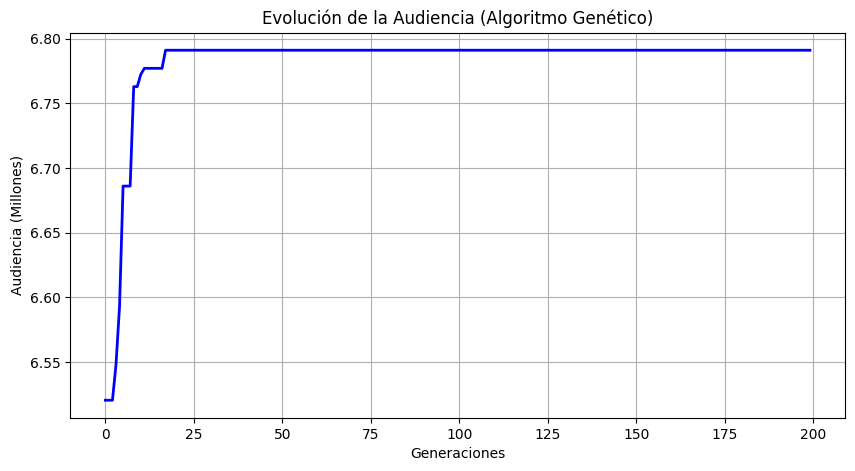


RESULTADO FINAL:
Mejor Solución: [3, 8, 0, 4, 9, 5, 2, 6, 7, 1]
Audiencia Máxima: 6.79 Millones


In [5]:

# Estos valores controlan cómo evoluciona el algoritmo
POBLACION_SIZE = 100      # Número de individuos (soluciones) en cada generación
GENERACIONES = 200        # Número de generaciones (iteraciones del algoritmo)
TASA_MUTACION = 0.1       # Probabilidad de que un individuo mute (10%)
ELITISMO = 10             # Número de mejores individuos que se copian sin cambios a la siguiente generación



# Crea una solución aleatoria pero que respeta las restricciones (viernes y lunes)
def generar_individuo():
    # Crea una solución aleatoria válida
    
    # Crear lista con IDs de todos los partidos (0-9)
    partidos = list(range(10))
    
    # Barajar aleatoriamente los partidos
    random.shuffle(partidos)  # Desordenamos la lista de partidos
    
    # Asignar el primer partido barajado al viernes (horario 0)
    idx_viernes = partidos[0]  # El primer elemento después del shuffle
    
    # Asignar el segundo partido barajado al lunes (horario 9)
    idx_lunes = partidos[1]    # El segundo elemento después del shuffle
    
    # El resto de partidos (índices 2-9 de la lista barajada) van al fin de semana
    restantes = partidos[2:]   # Partidos del 3º en adelante (8 partidos)
    
    # Crear lista vacía para la solución (-1 significa sin asignar)
    individuo = [-1] * 10  # Una posición por cada partido
    
    # Asignar viernes
    individuo[idx_viernes] = 0  # índice=partido_id, valor=horario (0=viernes)
    
    # Asignar lunes
    individuo[idx_lunes] = 9    # índice=partido_id, valor=horario (9=lunes)
    
    # Asignar el fin de semana
    # Para cada partido restante, asignar un horario aleatorio entre 1 y 8
    for p in restantes:
        individuo[p] = random.randint(1, 8)  # Horarios 1-8 son para sábado y domingo
    
    # Retornar el individuo completo y válido
    return individuo


# Combina dos soluciones parentales para crear dos soluciones hijas
def cruce(padre1, padre2):
    # padre1, padre2: dos soluciones (listas de 10 elementos)
    
    # Seleccionar puntos de cruce aleatorios
    # entre 1 y 6 (para garantizar segmentos mínimos)
    punto1 = random.randint(1, 6)
    
    # entre punto1+1 y 8 (para garantizar que punto2 > punto1)
    punto2 = random.randint(punto1 + 1, 8)
    
    # Aplicar cruce en dos puntos
    # Hijo 1: primeros genes del padre1, medio del padre2, final del padre1
    hijo1 = padre1[:punto1] + padre2[punto1:punto2] + padre1[punto2:]
    
    # Hijo 2: primeros genes del padre2, medio del padre1, final del padre2
    hijo2 = padre2[:punto1] + padre1[punto1:punto2] + padre2[punto2:]
    
    # Paso 3: Asegurar que los hijos respetan las restricciones (viernes y lunes únicos)
    # Es posible que el cruce haya creado múltiples viernes o lunes, hay que corregir
    # Retornar ambos hijos después de corregir sus restricciones
    return corregir_restricciones(hijo1), corregir_restricciones(hijo2)

# Cambia aleatoriamente un gene (horario) de un individuo
def mutar(individuo):
    # Generar número aleatorio entre 0 y 1
    # Si es menor que TASA_MUTACION (0.1), aplicar mutación
    if random.random() < TASA_MUTACION:
        # Seleccionar un partido aleatorio (0-9)
        idx_partido = random.randint(0, 9)
        
        # Asignarle un nuevo horario aleatorio
        nuevo_horario = random.randint(0, 9)  # Cualquier horario (0-9)
        
        # Aplicar el cambio
        individuo[idx_partido] = nuevo_horario
    
    # Corregir restricciones (puede que hayamos creado múltiples viernes/lunes)
    return corregir_restricciones(individuo)


# Asegura que siempre hay exactamente un viernes y un lunes
def corregir_restricciones(ind):
    # Función de limpieza para asegurar que hay exactamente un partido el viernes (0) y uno el lunes (9)
    
    # Buscar todos los índices de partidos asignados al viernes
    indices_v = [i for i, h in enumerate(ind) if h == 0]  # Lista de índices con h==0
    
    if not indices_v:  # Si no hay ningún viernes
        # Elegir un partido aleatorio y asignarlo al viernes
        ind[random.randint(0, 9)] = 0
    elif len(indices_v) > 1:  # Si hay múltiples viernes
        # Mantener el primero, asignar el resto al fin de semana
        for i in indices_v[1:]:  # Para todos menos el primero
            ind[i] = random.randint(1, 8)  # Horario aleatorio del fin de semana
    
    # Buscar todos los índices de partidos asignados al lunes
    indices_l = [i for i, h in enumerate(ind) if h == 9]  # Lista de índices con h==9
    
    if not indices_l:  # Si no hay ningún lunes
        # Elegir un partido que NO sea el del viernes
        idx = random.choice([i for i, h in enumerate(ind) if h != 0])
        ind[idx] = 9
    elif len(indices_l) > 1:  # Si hay múltiples lunes
        # Mantener el primero, asignar el resto al fin de semana
        for i in indices_l[1:]:  # Para todos menos el primero
            ind[i] = random.randint(1, 8)  # Horario aleatorio del fin de semana
    
    # Retornar individuo corregido
    return ind


# Implementa el ciclo completo de evolución
def algoritmo_genetico(partidos, audiencia_base, coeficientes, penalizaciones):
    # partidos: Lista de diccionarios con info de partidos
    # audiencia_base: Diccionario con audiencias por categorías
    # coeficientes: Lista con coeficientes de horario
    # penalizaciones: Lista con penalizaciones por coincidencias
    
    # Generar POBLACION_SIZE (100) individuos aleatorios válidos
    poblacion = [generar_individuo() for _ in range(POBLACION_SIZE)]
    
    # Variables para rastrear la mejor solución global encontrada
    mejor_global = None            # La mejor solución en toda la ejecución
    mejor_audiencia_global = -1    # Audiencia de la mejor solución
    
    # Lista para almacenar el histórico de audiencias (para gráfico)
    historial_audiencias = []
    
    # EVOLUCIONAR DURANTE N GENERACIONES
    for gen in range(GENERACIONES):  # gen va de 0 a 199 (200 generaciones)
        
        # Ordenar población de mejor a peor según función objetivo (calcular_audiencia)
        # reverse=True: orden descendente (mejores primero)
        poblacion = sorted(
            poblacion,
            key=lambda ind: calcular_audiencia(ind, partidos, audiencia_base, coeficientes, penalizaciones),
            reverse=True
        )
        
        # OBTENER EL MEJOR INDIVIDUO DE ESTA GENERACIÓN
        actual_mejor_ind = poblacion[0]  # Primer elemento
        actual_mejor_aud = calcular_audiencia(actual_mejor_ind, partidos, audiencia_base, coeficientes, penalizaciones)
        
        # ACTUALIZAR MEJOR GLOBAL SI ES NECESARIO
        if actual_mejor_aud > mejor_audiencia_global:
            mejor_audiencia_global = actual_mejor_aud
            mejor_global = actual_mejor_ind[:]  # Copiar la lista (no solo referencia)
        
        # GUARDAR HISTÓRICO PARA GRÁFICO
        # Guardamos el mejor global (no solo el de esta generación)
        historial_audiencias.append(mejor_audiencia_global)
        
        # Copiar los ELITISMO (10) mejores individuos sin cambios a la siguiente generación
        nueva_poblacion = poblacion[:ELITISMO]  # Los primeros 10 (ya ordenados)
        
        # crear nuevos individuos para llenar población
        # Mientras nueva_poblacion tenga menos de POBLACION_SIZE (100)
        while len(nueva_poblacion) < POBLACION_SIZE:
            # Seleccionar dos padres de los 50 mejores (para presión selectiva)
            p1 = random.choice(poblacion[:50])  # Padre 1 elegido de top 50
            p2 = random.choice(poblacion[:50])  # Padre 2 elegido de top 50
            
            # Aplicar cruce (recombinación) a los padres
            hijo1, hijo2 = cruce(p1, p2)
            
            # Aplicar mutación a cada hijo
            hijo1 = mutar(hijo1)
            hijo2 = mutar(hijo2)
            
            # Añadir el primer hijo a la nueva población
            nueva_poblacion.append(hijo1)
            
            # Si hay espacio, añadir también el segundo hijo
            # Esto previene agregar un hijo extra si POBLACION_SIZE es impar
            if len(nueva_poblacion) < POBLACION_SIZE:
                nueva_poblacion.append(hijo2)
        
        # REEMPLAZAR POBLACIÓN
        # La nueva población (con élite + hijos mutados) se convierte en la población actual
        poblacion = nueva_poblacion
    
    # VISUALIZACIÓN DEL HISTÓRICO DE CONVERGENCIA
    # Crear gráfico de cómo mejora la audiencia a lo largo de las generaciones
    plt.figure(figsize=(10, 5))
    plt.plot(historial_audiencias, color='blue', linewidth=2)
    plt.title("Evolución de la Audiencia (Algoritmo Genético)")
    plt.xlabel("Generaciones")
    plt.ylabel("Audiencia (Millones)")
    plt.grid(True)
    plt.show()
    
    # Devolver la mejor solución encontrada y su audiencia
    return mejor_global, mejor_audiencia_global



# Llamar al algoritmo con los datos de ejemplo
mejor_sol, mejor_aud = algoritmo_genetico(partidos_ejemplo, audiencia_base, coeficientes_horario, penalizacion_coincidencia)

# Mostrar resultados finales
print(f"\nRESULTADO FINAL:")
print(f"Mejor Solución: {mejor_sol}")
print(f"Audiencia Máxima: {mejor_aud:.2f} Millones")

(*)Calcula la complejidad del algoritmo

Para determinar la complejidad de este Algoritmo Genético, debemos analizar el coste de sus componentes principales en función de las variables de control (hiperparámetros) y el tamaño del problema:

* **G**: Número de generaciones (`GENERACIONES` = 200).
* **P**: Tamaño de la población (`POBLACION_SIZE` = 100).
* **N**: Número de partidos a programar ($N = 10$).

#### 1. Fase de Inicialización
Se crean $P$ individuos aleatorios. Cada individuo requiere una permutación y asignaciones de tamaño $N$.
* **Complejidad:** $O(P \cdot N)$

#### 2. Bucle de Evolución (se repite $G$ veces)
Dentro de cada generación, el algoritmo realiza las siguientes operaciones:

* **Evaluación y Ordenación:** Se calcula la audiencia para cada individuo. La función `calcular_audiencia` recorre los $N$ partidos y verifica coincidencias, lo que tiene un coste de $O(N^2)$

    * La ordenación de la población (`sorted`) utiliza el algoritmo Timsort de Python, con un coste de $O(P \log P)$.
    * *Subtotal:* $O(P \cdot N^2 + P \log P)$

* **Selección y Elitismo:** Se copian los mejores individuos (`ELITISMO`). Es una operación de particionado (slicing) de coste $O(P)$.

* **Reproducción (Cruce y Mutación):**
    * Se generan nuevos individuos hasta completar la población ($P - ELITISMO$).
    * Las funciones de `cruce`, `mutar` y `corregir_restricciones` realizan recorridos y manipulaciones lineales sobre listas de tamaño $N$.
    * *Subtotal:* $O(P \cdot N)$

#### 3. Complejidad Total Asintótica

Sumando los costes y multiplicando por el número de generaciones, la complejidad total es:
**$$O(G \cdot (P \cdot N^2 + P \log P))$$**


A diferencia de la Fuerza Bruta, cuya complejidad es exponencial, el Algoritmo Genético presenta una complejidad polinómica. Esto permite encontrar soluciones de alta calidad en un tiempo constante y relativamente pequeño, independientemente de que el espacio de soluciones sea inmenso, ya que el tiempo de ejecución escala linealmente con el número de generaciones y el tamaño de la población.

Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

Respuesta

Para validar la robustez del algoritmo, hemos diseñado un generador de datos aleatorios que simula una jornada real de La Liga. Para que el juego de datos tenga sentido, hemos seguido estas reglas:

1. **Audiencia Base:** Cada partido tiene asignada una audiencia base proporcional a la categoría de los equipos. Hemos definido tres niveles:
   - **Clase A:** 2 millones (ej. Madrid vs Barça).
   - **Clase B:** 1 millón.
   - **Clase C:** 0.5 millones.

2. **Estructura:** Se generan exactamente 10 partidos.

3. **Coeficientes y Penalizaciones:** Se mantienen los coeficientes por horario y las penalizaciones por coincidencia definidos en el enunciado, ya que son parámetros constantes del modelo de negocio de La Liga.

In [6]:

# Crea un juego de datos sintético para validar el algoritmo
def generar_juego_datos_aleatorio():
    # Sin parámetros: genera un juego de datos interno
    
    # DEFINIR CATEGORÍAS DE EQUIPOS
    # Tres niveles: A (elite), B (medio), C (pequeños)
    categorias = ['A', 'B', 'C']
    
    # INICIALIZAR LISTA DE PARTIDOS
    nuevos_partidos = []  # Acumulador de partidos generados
    
    # DEFINIR AUDIENCIAS BASE
    # Misma estructura que antes, pero la generamos aquí como parte del juego de datos
    nuevas_audiencias_base = {
        ('A', 'A'): 2.0,    # Top vs Top
        ('A', 'B'): 1.3,    # Elite vs Medio
        ('A', 'C'): 1.0,    # Elite vs Pequeño
        ('B', 'A'): 1.3,    # Medio vs Elite (simétrico)
        ('B', 'B'): 0.9,    # Medio vs Medio
        ('B', 'C'): 0.75,   # Medio vs Pequeño
        ('C', 'A'): 1.0,    # Pequeño vs Elite (simétrico)
        ('C', 'B'): 0.75,   # Pequeño vs Medio (simétrico)
        ('C', 'C'): 0.47    # Pequeño vs Pequeño
    }
    
    # GENERAR 10 PARTIDOS ALEATORIOS
    # Iteramos 10 veces, una por cada partido
    for i in range(10):
        # Seleccionar categoría aleatoria para equipo 1
        c1 = random.choice(categorias)  # Elige 'A', 'B' o 'C' aleatoriamente
        
        # Seleccionar categoría aleatoria para equipo 2
        c2 = random.choice(categorias)  # Elige 'A', 'B' o 'C' aleatoriamente
        
        # PASO 5: CREAR DICCIONARIO DEL PARTIDO
        # Estructura: nombres descriptivos y categorías
        partido_dict = {
            'nombre': f"Equipo_{c1}_{i} vs Equipo_{c2}_{i}",  # Nombre descriptivo (Equipo_A_0 vs Equipo_B_0)
            'cat1': c1,  # Categoría del primer equipo
            'cat2': c2   # Categoría del segundo equipo
        }
        
        # PASO 6: AGREGAR PARTIDO A LA LISTA
        nuevos_partidos.append(partido_dict)
    
    # RETORNAR DATOS GENERADOS
    # Devolver los partidos generados y las audiencias base
    return nuevos_partidos, nuevas_audiencias_base


# Generamos un juego de datos aleatorio
partidos_aleatorios, audiencias_base_aleatorias = generar_juego_datos_aleatorio()

# Mostrar los datos generados para verificación
print("JUEGO DE DATOS GENERADO (Formato Diccionario):")
for i, p in enumerate(partidos_aleatorios):
    print(f"Partido {i+1}: {p['nombre']} | Categorías: {p['cat1']}-{p['cat2']}")

JUEGO DE DATOS GENERADO (Formato Diccionario):
Partido 1: Equipo_B_0 vs Equipo_C_0 | Categorías: B-C
Partido 2: Equipo_B_1 vs Equipo_B_1 | Categorías: B-B
Partido 3: Equipo_A_2 vs Equipo_C_2 | Categorías: A-C
Partido 4: Equipo_A_3 vs Equipo_B_3 | Categorías: A-B
Partido 5: Equipo_C_4 vs Equipo_C_4 | Categorías: C-C
Partido 6: Equipo_C_5 vs Equipo_C_5 | Categorías: C-C
Partido 7: Equipo_C_6 vs Equipo_A_6 | Categorías: C-A
Partido 8: Equipo_C_7 vs Equipo_B_7 | Categorías: C-B
Partido 9: Equipo_B_8 vs Equipo_B_8 | Categorías: B-B
Partido 10: Equipo_B_9 vs Equipo_C_9 | Categorías: B-C


Aplica el algoritmo al juego de datos generado

Procedemos a ejecutar el Algoritmo Genético sobre el juego de datos generado aleatoriamente. Esta prueba permite verificar que el algoritmo es capaz de converger hacia una solución óptima independientemente de los valores de audiencia base de entrada, respetando siempre las restricciones de calendario.

Respuesta

Ejecutando Algoritmo Genético sobre datos aleatorios...



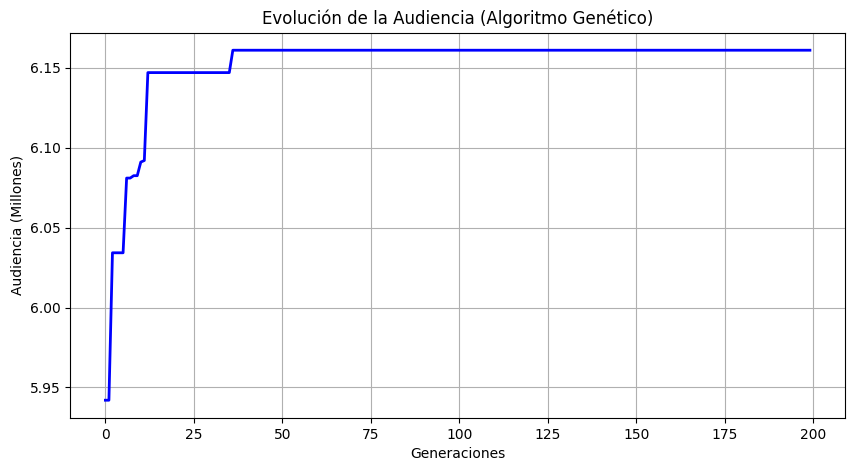


RESULTADO CON DATOS ALEATORIOS:
Mejor Solución (Horarios): [2, 1, 3, 8, 0, 9, 4, 6, 7, 5]
Audiencia Máxima Lograda: 6.16 Millones

Planificación detallada:
Horario 2: Equipo_B_0 vs Equipo_C_0
Horario 1: Equipo_B_1 vs Equipo_B_1
Horario 3: Equipo_A_2 vs Equipo_C_2
Horario 8: Equipo_A_3 vs Equipo_B_3
Horario 0: Equipo_C_4 vs Equipo_C_4
Horario 9: Equipo_C_5 vs Equipo_C_5
Horario 4: Equipo_C_6 vs Equipo_A_6
Horario 6: Equipo_C_7 vs Equipo_B_7
Horario 7: Equipo_B_8 vs Equipo_B_8
Horario 5: Equipo_B_9 vs Equipo_C_9


In [7]:
# Aplicamos el algoritmo genético
print("Ejecutando Algoritmo Genético sobre datos aleatorios...\n")

mejor_sol_aleatoria, mejor_aud_aleatoria = algoritmo_genetico(
    partidos_aleatorios,           # Los 10 partidos con categorías aleatorias
    audiencias_base_aleatorias,    # Las audiencias base (mismas para todos)
    coeficientes_horario,          # Los coeficientes de horario (fijos)
    penalizacion_coincidencia      # Las penalizaciones por coincidencia (fijas)
)

print(f"\nRESULTADO CON DATOS ALEATORIOS:")
print(f"Mejor Solución (Horarios): {mejor_sol_aleatoria}")
print(f"Audiencia Máxima Lograda: {mejor_aud_aleatoria:.2f} Millones")

print("\nPlanificación detallada:")
for i in range(10):
    # Acceder al nombre del partido (está dentro del diccionario)
    nombre_partido = partidos_aleatorios[i]['nombre']  # Obtener nombre del diccionario
    horario_asignado = mejor_sol_aleatoria[i]         # Obtener horario de la solución
    print(f"Horario {horario_asignado}: {nombre_partido}")
    # Mostramos: "Horario 0: Equipo_A_0 vs Equipo_B_3"

Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

Respuesta

Para el desarrollo de este proyecto, se han consultado las siguientes fuentes bibliográficas a parte de los apuntes de la asignatura:

1. **GeeksforGeeks - Genetic Algorithms**: Consultada para la implementación de los operadores de selección, cruce y mutación, así como para la gestión del elitismo en la población. 
   *(https://www.geeksforgeeks.org/genetic-algorithms/)*

2. **Towards Data Science - Sports Scheduling Optimization**: Utilizada como referencia para comprender la modelización de la audiencia televisiva como función objetivo en problemas de optimización combinatoria.
   *(https://towardsdatascience.com/solving-the-sports-scheduling-problem-with-python)*

3. **ResearchGate - Metaheuristics for League Scheduling**: Artículo de referencia sobre el estado del arte en la resolución de calendarios deportivos mediante técnicas metaheurísticas para minimizar conflictos de horarios.

Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

Respuesta

Para llevar este estudio al siguiente nivel, creo que el paso más lógico sería empezar a movernos hacia un enfoque de algoritmos meméticos. Esto básicamente significa no quedarnos solo con la evolución genética, sino "enseñar" a los hijos a mejorar por su cuenta mediante una búsqueda local rápida antes de pasar a la siguiente generación, lo que aceleraría muchísimo la convergencia en ligas más grandes.  También sería súper interesante meterle capas de realidad que ahora mismo no tenemos, como el cansancio de los jugadores (que no puedan jugar dos partidos en menos de 48 horas) o incluso usar modelos de Machine Learning que predigan la audiencia basándose en cómo van los equipos en la clasificación en ese momento, en lugar de usar números fijos.

Si quisiéramos escalar el problema a toda una temporada completa o a competiciones europeas, tendríamos que empezar a mirar algoritmos multiobjetivo que no solo busquen el dinero de la tele, sino que también cuiden el descanso de los deportistas y no pongan horarios imposibles para la gente que va a los estadios. Al final, el objetivo sería convertir esta herramienta en un asistente de gestión integral para la toma de decisiones en el calendario deportivo.